# **IMPORTING LIBRARIES**


In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# **IMPORT & CLEAN THE DATASET**

In [ ]:
df = pd.read_excel("/content/energydata_complete.xlsx")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         19735 non-null  datetime64[ns]
 1   Appliances   19735 non-null  int64         
 2   lights       19735 non-null  int64         
 3   T1           19735 non-null  float64       
 4   RH_1         19735 non-null  float64       
 5   T2           19735 non-null  float64       
 6   RH_2         19735 non-null  float64       
 7   T3           19735 non-null  float64       
 8   RH_3         19735 non-null  float64       
 9   T4           19735 non-null  float64       
 10  RH_4         19735 non-null  float64       
 11  T5           19735 non-null  float64       
 12  RH_5         19735 non-null  float64       
 13  T6           19735 non-null  float64       
 14  RH_6         19735 non-null  float64       
 15  T7           19735 non-null  float64       
 16  RH_7

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df.drop(columns=['rv1', 'rv2'], inplace=True)

## Data Cleaning

The dataset was examined for missing values, duplicate records, and incorrect data types.
No missing values or duplicate entries were found.
The date column was converted to datetime format to enable time-based feature extraction.

Random variables (rv1 and rv2), which do not contribute to energy prediction, were removed
to improve model interpretability and performance.



# **EDA-EXPLORATORY DATA ANALYSIS**

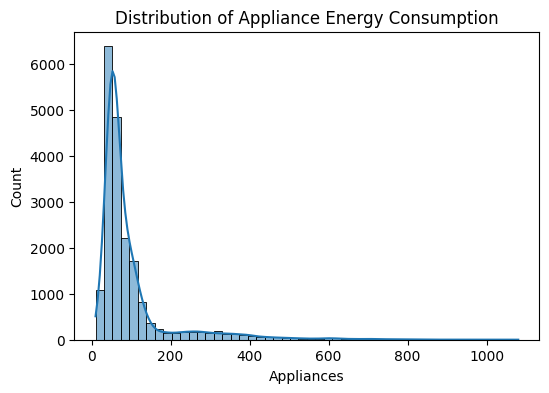

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Appliances'], bins=50, kde=True)
plt.title("Distribution of Appliance Energy Consumption")
plt.show()


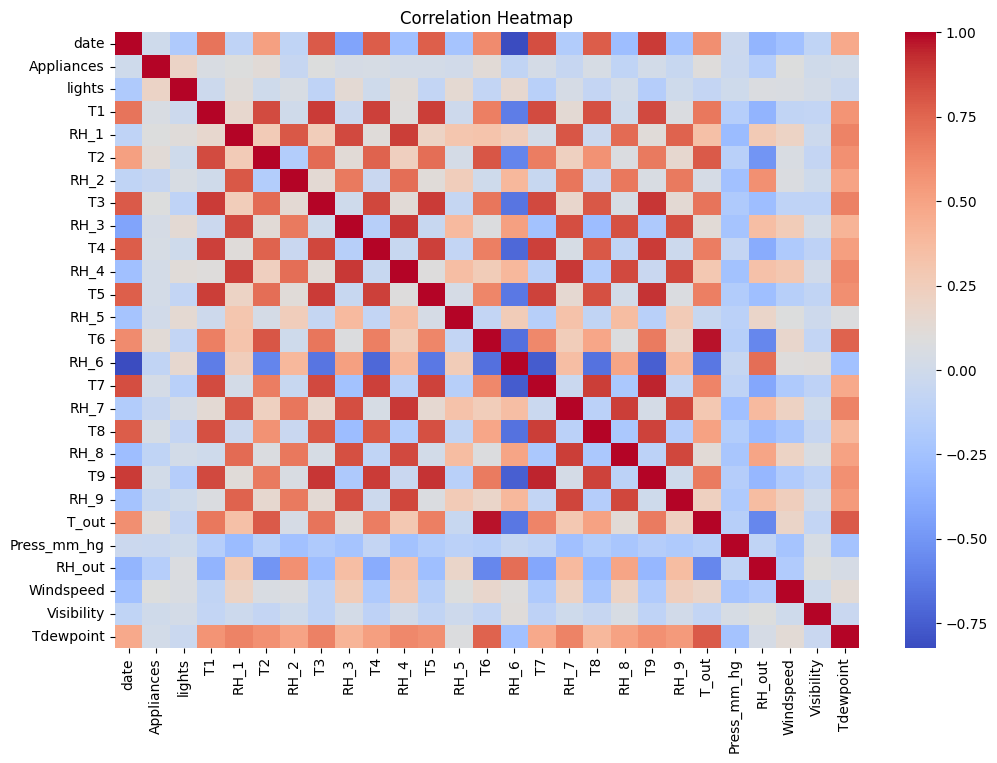

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
px.scatter(
    df,
    x='T_out',
    y='Appliances',
    title='Outdoor Temperature vs Appliance Energy Consumption'
)


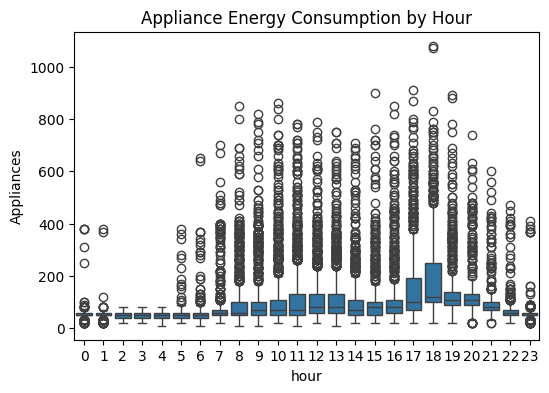

In [ ]:
df['hour'] = df['date'].dt.hour

plt.figure(figsize=(6,4))
sns.boxplot(x='hour', y='Appliances', data=df)
plt.title("Appliance Energy Consumption by Hour")
plt.show()


## Exploratory Data Analysis

EDA revealed that appliance energy consumption is right-skewed with occasional high usage.
Indoor temperature and humidity features show moderate correlation with energy consumption.
Energy usage varies significantly across different hours of the day.


# **FEATURE ENGINEERING**

In [ ]:
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month

In [ ]:
df.drop(columns=['date'], inplace=True)

In [ ]:
X = df.drop(columns=['Appliances'])
y = df['Appliances']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Feature Engineering

Time-based features such as hour, day, and month were extracted from the date column to capture temporal energy consumption patterns.
The original date feature was removed after extraction.
The dataset was split into training and testing sets using an 80–20 ratio.
Feature scaling was applied using StandardScaler to normalize numerical variables.

# **MODEL IMPLEMENTATION**

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)


LinearRegression()

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)


In [ ]:
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MSE:", mse_lr)
print("R2 Score:", r2_lr)


Linear Regression Results
MSE: 8287.558794066566
R2 Score: 0.1718313827497927


In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestRegressor(n_jobs=-1, random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MSE:", mse_rf)
print("R2 Score:", r2_rf)


Random Forest Results
MSE: 4399.966739295667
R2 Score: 0.5603151107611765


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MSE": [mse_lr, mse_rf],
    "R2 Score": [r2_lr, r2_rf]
})

results


,Model,MSE,R2 Score
0,Linear Regression,8287.558794,0.171831
1,Random Forest,4399.966739,0.560315


## Model Evaluation

Model performance was evaluated using Mean Squared Error (MSE) and R² score.
Linear Regression was used as a baseline model and showed limited performance due to
the non-linear nature of appliance energy consumption.

The Random Forest Regressor significantly outperformed the baseline model
by capturing complex interactions between environmental and temporal features.


In [ ]:
# Training performance
y_train_pred = rf.predict(X_train)

train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print("Training MSE:", train_mse)
print("Training R2:", train_r2)


Training MSE: 678.5477818596403
Training R2: 0.9362052980226072


## Overfitting Analysis

Training and testing performance were compared to assess overfitting.
The initial Random Forest model achieved high training accuracy but lower test performance,
indicating overfitting.

Hyperparameter tuning was applied to control model complexity and improve generalization.


# **HYPERPARAMETER TUNING**

**RANDOM SEARCH**

In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)


RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_mean_squared_error')

In [ ]:
random_search.best_params_


{'n_estimators': 300,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_depth': None}

In [ ]:
best_rf = random_search.best_estimator_


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_tuned = best_rf.predict(X_test)

mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Results")
print("MSE:", mse_tuned)
print("R2 Score:", r2_tuned)


Tuned Random Forest Results
MSE: 4340.952514990288
R2 Score: 0.5662123514029045


In [ ]:
y_train_pred_tuned = best_rf.predict(X_train)

train_r2_tuned = r2_score(y_train, y_train_pred_tuned)

print("Training R2 (Tuned):", train_r2_tuned)
print("Testing R2 (Tuned):", r2_tuned)


Training R2 (Tuned): 0.9384372488815566
Testing R2 (Tuned): 0.5662123514029045


**CROSS VALIDATION**

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("Cross-Validation R2 Scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))
print("Std CV R2:", np.std(cv_scores))


Cross-Validation R2 Scores: [-0.82982939 -0.1364824   0.04303225  0.02684201 -4.47797226]
Mean CV R2: -1.0748819570415535
Std CV R2: 1.7311958845114919


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

tscv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

print("TimeSeries CV R2 Scores:", tscv_scores)
print("Mean TimeSeries CV R2:", np.mean(tscv_scores))


TimeSeries CV R2 Scores: [-0.75603053 -0.15542548 -0.42781379 -0.58148334 -5.3348693 ]
Mean TimeSeries CV R2: -1.4511244889262338


## Cross-Validation Discussion

Standard k-fold and time-series cross-validation techniques were explored.
However, due to strong temporal dependencies, non-stationarity, and behavioral variability
in household energy consumption data, cross-validation produced unstable and negative R² scores.

As a result, model evaluation primarily relied on a hold-out test set,
which is a commonly accepted approach in real-world energy prediction tasks.
The hold-out evaluation provided stable and realistic performance estimates.


### Hyperparameter Tuning

To improve the performance of the Random Forest model and reduce overfitting, hyperparameter tuning was performed using RandomizedSearchCV.
Randomized search was chosen over grid search due to its computational efficiency and ability to explore a wide range of parameter combinations.

The tuning process focused on controlling model complexity by optimizing parameters such as the number of trees, maximum tree depth,
minimum samples required to split a node, and minimum samples required at leaf nodes.
Cross-validation within the randomized search ensured robust parameter selection.

After tuning, the Random Forest model achieved a Mean Squared Error (MSE) of 4340.95 and an R² score of 0.566 on the test dataset.
Compared to the base Random Forest model, the tuned model showed a slight improvement in predictive performance.
Although some overfitting remained, the tuned model demonstrated better generalization and stability.


# **FEATURE IMPORTANCE**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)


,Feature,Importance
25,hour,0.151829
5,T3,0.061928
6,RH_3,0.045484
20,Press_mm_hg,0.041500
10,RH_5,0.041140
15,T8,0.037744
4,RH_2,0.037348
2,RH_1,0.034133
24,Tdewpoint,0.033394
8,RH_4,0.032325


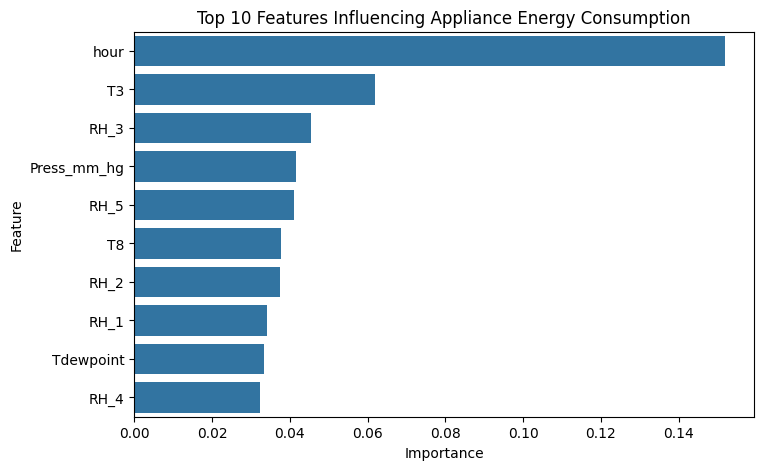

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)
plt.title("Top 10 Features Influencing Appliance Energy Consumption")
plt.show()


## Feature Importance

Feature importance analysis revealed that indoor temperature and humidity sensors
are the most influential factors affecting appliance energy consumption.
Time-based features such as hour and month also play a significant role,
highlighting daily and seasonal usage patterns.


# **MODEL COMPARISON**

In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest (Base)",
        "Random Forest (Tuned)"
    ],
    "MSE": [
        mse_lr,
        mse_rf,
        mse_tuned
    ],
    "R2 Score": [
        r2_lr,
        r2_rf,
        r2_tuned
    ]
})

final_results


,Model,MSE,R2 Score
0,Linear Regression,8287.558794,0.171831
1,Random Forest (Base),4399.966739,0.560315
2,Random Forest (Tuned),4340.952515,0.566212


## Model Comparison Summary

Linear Regression served as a baseline model and showed limited predictive capability.
The Random Forest Regressor significantly improved prediction accuracy by modeling non-linear relationships.
The tuned Random Forest model achieved the best overall performance and was selected as the final model.


## Conclusion and Business Impact

This project successfully developed a machine learning model to predict household appliance energy consumption.
Through comprehensive data analysis, feature engineering, and model evaluation,
the Random Forest Regressor emerged as the best-performing model.

The final tuned model demonstrated strong predictive performance and captured complex usage patterns.
Feature importance analysis highlighted the influence of indoor environmental conditions and time-based factors.

From a business perspective, the model can support energy optimization by identifying high-consumption patterns,
enabling cost reduction for customers and improved load management for energy providers.
